In [ ]:
# notebook for building CNN with cats & dogs dataset

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

### Importing the raw cat and dog images

In [4]:
# importing the data (cat and dog images)

data_dir = "cats_dogs"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [20]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [7]:
# View labels from the first training batch

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


In [21]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


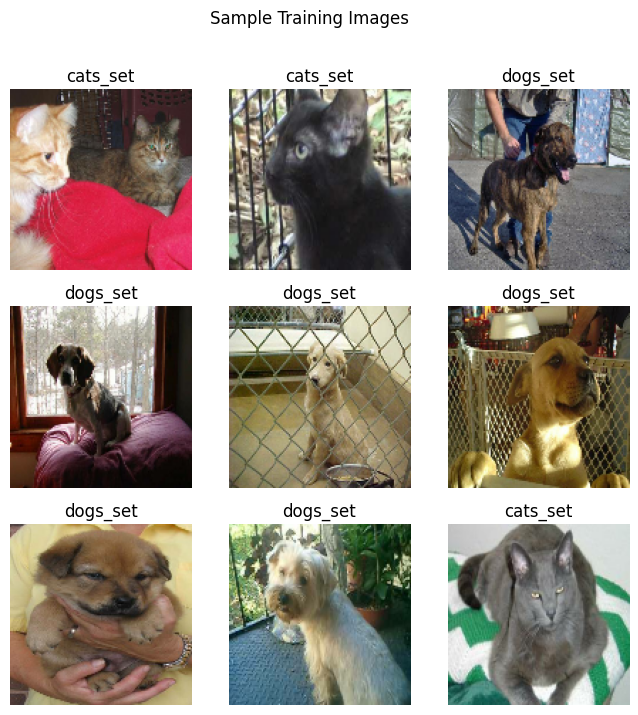

In [9]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [22]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


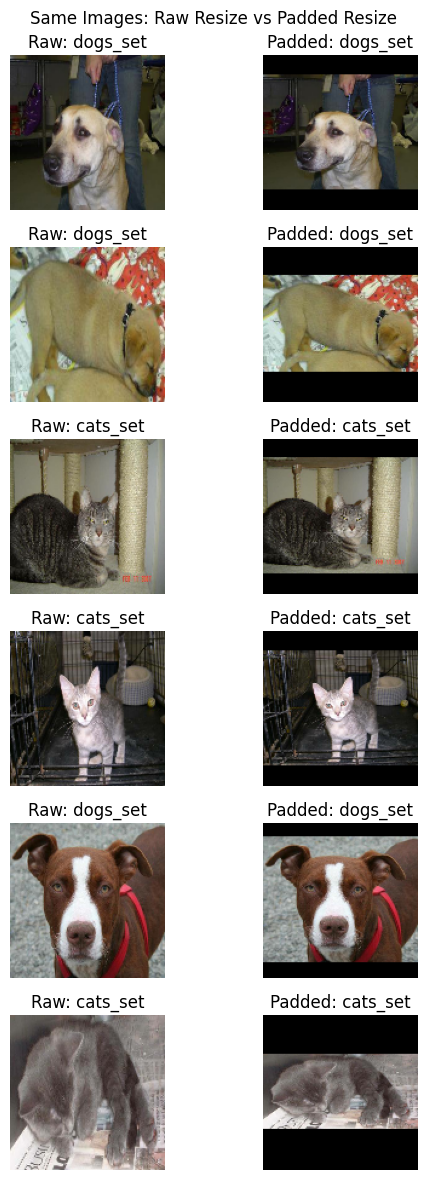

In [11]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [23]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [24]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


### Building the MLP model

In [25]:
# set random seed for reproducibility
tf.random.set_seed(42)  

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8700 - loss: 0.3187 - val_accuracy: 0.5385 - val_loss: 1.0826
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8438 - loss: 0.3594 - val_accuracy: 0.5192 - val_loss: 1.0842
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8450 - loss: 0.3385 - val_accuracy: 0.4712 - val_loss: 1.1008
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9062 - loss: 0.2692 - val_accuracy: 0.5673 - val_loss: 1.1537
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9000 - loss: 0.2708 - val_accuracy: 0.5385 - val_loss: 1.1074
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8975 - loss: 0.2757 - val_accuracy: 0.5385 - val_loss: 1.1692
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9137 - loss: 0.2198 - val_accuracy: 0.5288 - val_loss: 1.1137
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9287 - loss: 0.2062 - val_accuracy: 0.5577 - v

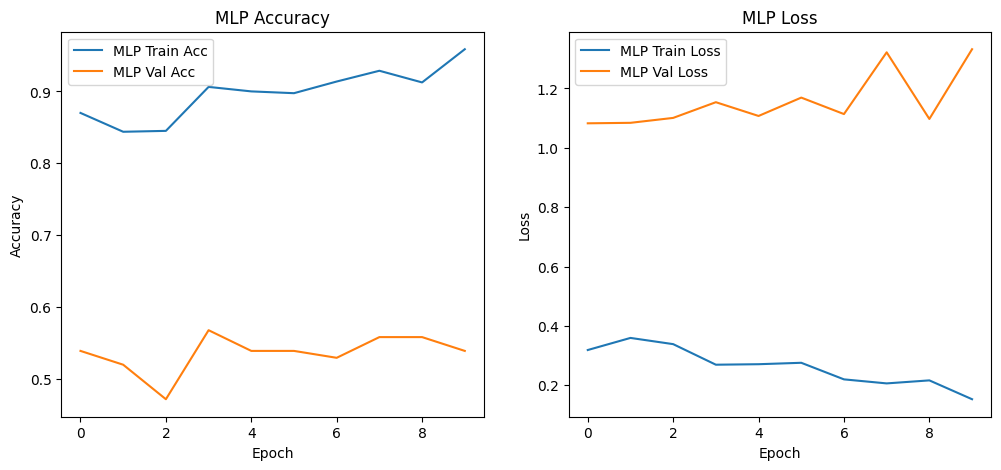

In [29]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [30]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - accuracy: 0.4900 - loss: 0.9852 - val_accuracy: 0.5385 - val_loss: 0.6914
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.5925 - loss: 0.6796 - val_accuracy: 0.5288 - val_loss: 0.6779
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 341ms/step - accuracy: 0.6237 - loss: 0.6449 - val_accuracy: 0.4904 - val_loss: 0.7239
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 366ms/step - accuracy: 0.6700 - loss: 0.5876 - val_accuracy: 0.5096 - val_loss: 0.7915
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 325ms/step - accuracy: 0.7663 - loss: 0.5008 - val_accuracy: 0.5673 - val_loss: 0.7730
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.8275 - loss: 0.3961 - val_accuracy: 0.6346 - val_loss: 0.6866
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 345ms/step - accuracy: 0.8712 - loss: 0.3082 - val_accuracy: 0.5288 - val_loss: 0.8874
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 386ms/step - accuracy: 0.9262 - loss: 0.2108 - val_accuracy:

### Visualizing CNN performance

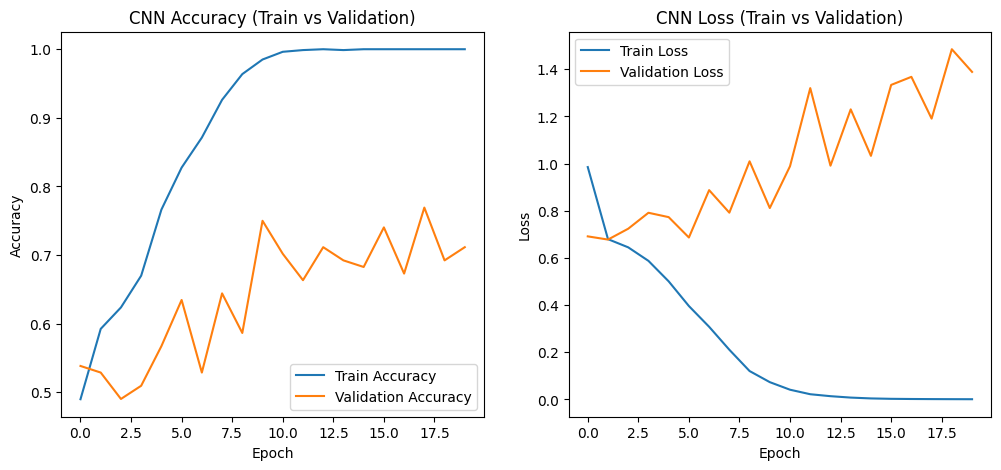

In [31]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [32]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)                   

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.5487 - loss: 0.8283 - val_accuracy: 0.5769 - val_loss: 0.6887
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.5825 - loss: 0.6735 - val_accuracy: 0.4808 - val_loss: 0.7207
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.6425 - loss: 0.6314 - val_accuracy: 0.5288 - val_loss: 0.7292
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 400ms/step - accuracy: 0.6938 - loss: 0.5836 - val_accuracy: 0.5962 - val_loss: 0.6562
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 417ms/step - accuracy: 0.7475 - loss: 0.5193 - val_accuracy: 0.6250 - val_loss: 0.6459
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.7987 - loss: 0.4402 - val_accuracy: 0.5962 - val_loss: 0.7414
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step - accuracy: 0.8550 - loss: 0.3559 - val_accuracy: 0.6346 - val_loss: 0.6451
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - accuracy: 0.8775 - loss: 0.3042 - val_accuracy

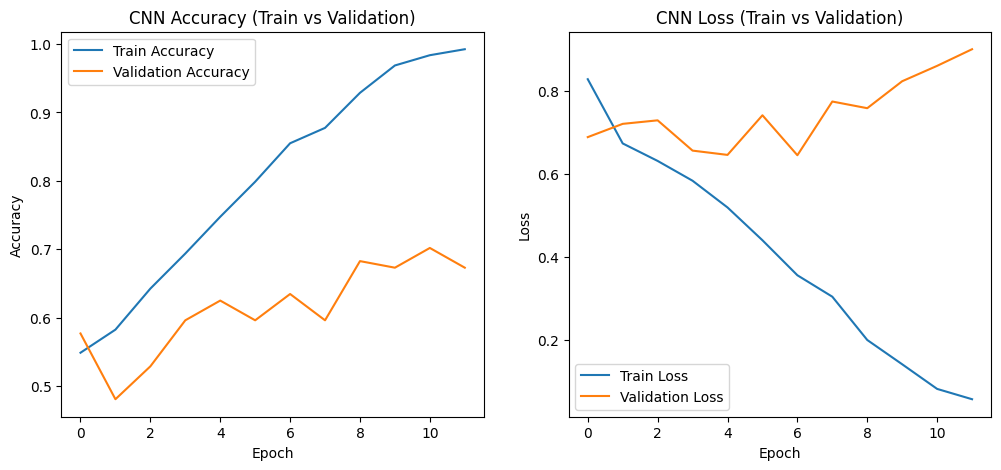

In [33]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [34]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.5487 - loss: 0.9258 - val_accuracy: 0.5192 - val_loss: 0.6919
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.5688 - loss: 0.6868 - val_accuracy: 0.5192 - val_loss: 0.7027
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step - accuracy: 0.5788 - loss: 0.6763 - val_accuracy: 0.5192 - val_loss: 0.7061
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 384ms/step - accuracy: 0.6062 - loss: 0.6665 - val_accuracy: 0.6250 - val_loss: 0.6711
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 334ms/step - accuracy: 0.5962 - loss: 0.6643 - val_accuracy: 0.5000 - val_loss: 0.7367
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.6200 - loss: 0.6463 - val_accuracy: 0.5288 - val_loss: 0.6965
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step - accuracy: 0.6250 - loss: 0.6333 - val_accuracy: 0.5192 - val_loss: 0.7043
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step - accuracy: 0.6575 - loss: 0.6282 - val_accuracy: 

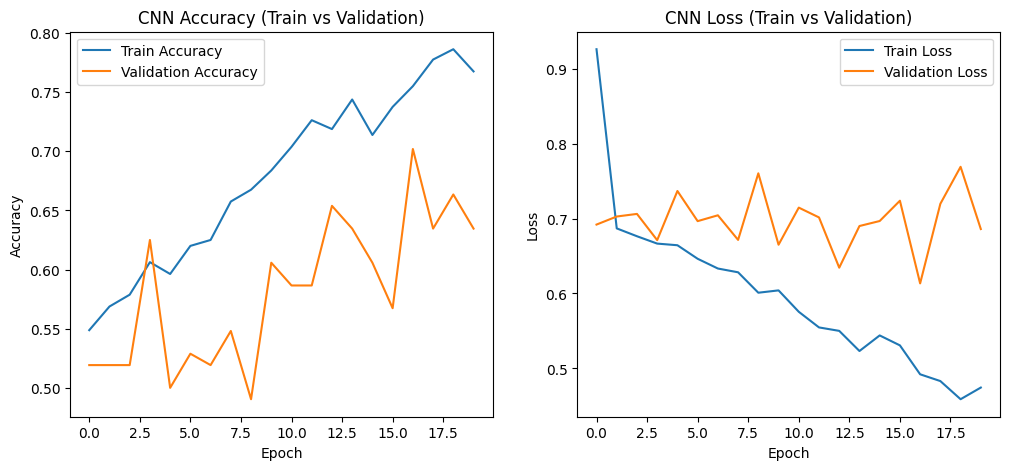

In [35]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [36]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - accuracy: 0.5775 - loss: 1.0461 - val_accuracy: 0.6058 - val_loss: 0.6770
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 330ms/step - accuracy: 0.6100 - loss: 0.6686 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step - accuracy: 0.6538 - loss: 0.6356 - val_accuracy: 0.5673 - val_loss: 0.6684
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 414ms/step - accuracy: 0.6675 - loss: 0.5982 - val_accuracy: 0.5962 - val_loss: 0.6946
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 399ms/step - accuracy: 0.6975 - loss: 0.5794 - val_accuracy: 0.5865 - val_loss: 0.6932
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.7350 - loss: 0.5305 - val_accuracy: 0.5865 - val_loss: 0.6926
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 326ms/step - accuracy: 0.7675 - loss: 0.4743 - val_accuracy: 0.5769 - val_loss: 0.7184
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 289ms/step - accuracy: 0.7800 - loss: 0.4680 - val_accuracy:

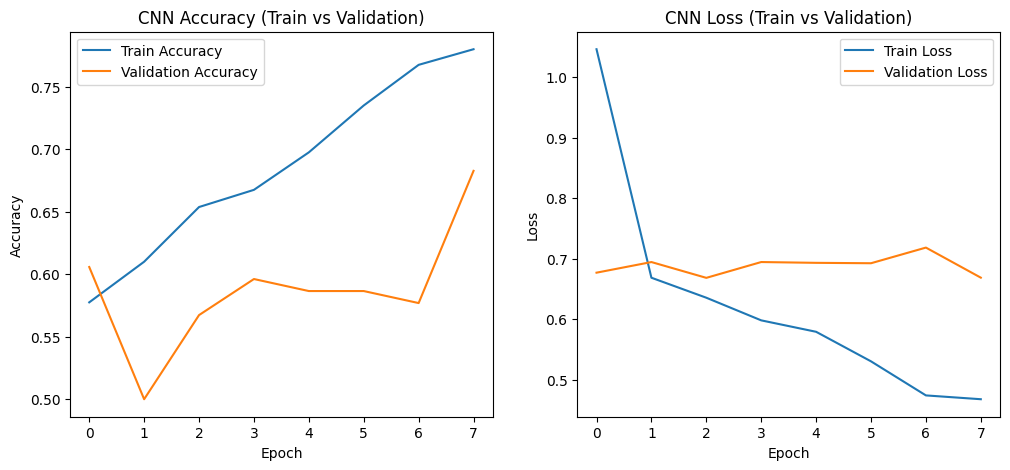

In [37]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

# Model 1: Light Augmentation CNN

This model uses a simple 32 → 64 CNN architecture with horizontal flipping and small rotation augmentation. The goal is to test whether light data augmentation improves generalization while keeping model capacity relatively small.

In [38]:
# Model 1: Simple CNN with light data augmentation
# This experiment tests whether light augmentation improves generalization
# while keeping the CNN architecture relatively simple.

tf.random.set_seed(42)

data_augmentation_1 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05)
])

early_stopping_1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

cnn_model_1 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation_1,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

cnn_model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_1 = cnn_model_1.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_1]
)

cnn_test_loss_1, cnn_test_acc_1 = cnn_model_1.evaluate(test_ds_padded)

print(f"Experiment 1 Test Accuracy: {cnn_test_acc_1:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.5312 - loss: 0.8549 - val_accuracy: 0.5192 - val_loss: 0.6885
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 305ms/step - accuracy: 0.5688 - loss: 0.6761 - val_accuracy: 0.5577 - val_loss: 0.6787
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step - accuracy: 0.5962 - loss: 0.6629 - val_accuracy: 0.4712 - val_loss: 0.7153
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.5987 - loss: 0.6458 - val_accuracy: 0.5385 - val_loss: 0.7223
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 364ms/step - accuracy: 0.6313 - loss: 0.6322 - val_accuracy: 0.6058 - val_loss: 0.6628
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.6662 - loss: 0.5969 - val_accuracy: 0.6058 - val_loss: 0.6859
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - accuracy: 0.6950 - loss: 0.5832 - val_accuracy: 0.6635 - val_loss: 0.6850
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 291ms/step - accuracy: 0.6950 - loss: 0.5623 - val_accuracy: 

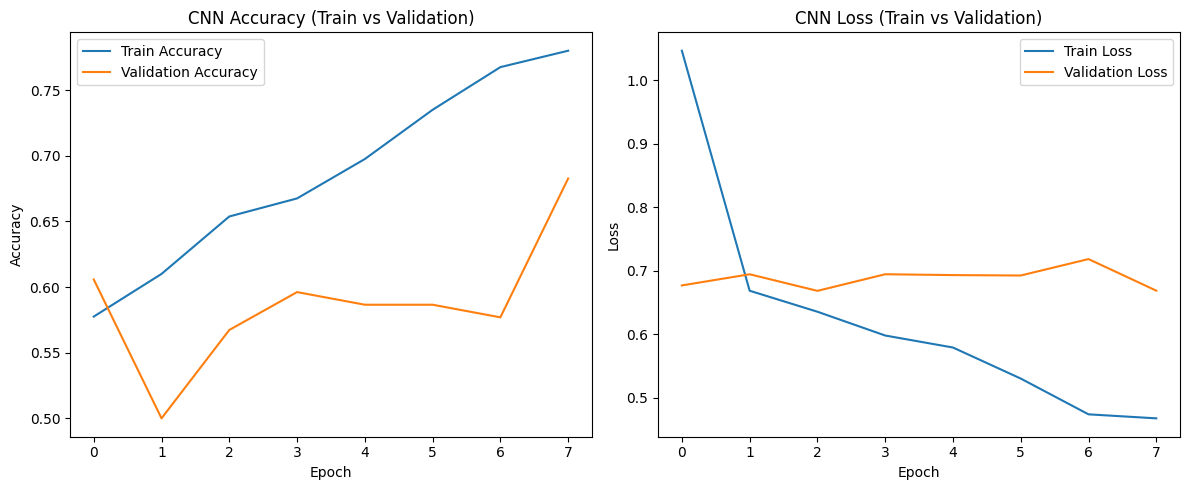

In [40]:
# visualizing training vs validation performance for Model 1

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(
    cnn_aug_history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    cnn_aug_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)

plt.plot(
    cnn_aug_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    cnn_aug_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.tight_layout()
plt.show()

The training curves showed that the CNN steadily improved performance on the training data, with training accuracy increasing and training loss consistently decreasing across epochs.

However, validation accuracy remained unstable and substantially lower than training accuracy throughout most epochs. Validation loss also remained relatively flat while training loss continued decreasing. This suggests that the model began overfitting the training images and struggled to generalize effectively to unseen validation data.

Although the CNN performed better than the earlier MLP model, the results indicate that additional regularization or stronger data augmentation may still be necessary to improve generalization performance.

# Model 2: Stronger augmentation + dropout


In [41]:
# This experiment tests whether stronger augmentation and dropout reduce overfitting.

tf.random.set_seed(42)

data_augmentation_2 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05)
])

early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

cnn_model_2 = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation_2,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

cnn_model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_2 = cnn_model_2.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_2]
)

cnn_test_loss_2, cnn_test_acc_2 = cnn_model_2.evaluate(test_ds_padded)

print(f"Model 2 Test Accuracy: {cnn_test_acc_2:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.5075 - loss: 0.8274 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.5700 - loss: 0.6807 - val_accuracy: 0.5288 - val_loss: 0.6897
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step - accuracy: 0.5738 - loss: 0.6735 - val_accuracy: 0.5769 - val_loss: 0.6744
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 483ms/step - accuracy: 0.6037 - loss: 0.6689 - val_accuracy: 0.5865 - val_loss: 0.7005
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 438ms/step - accuracy: 0.6037 - loss: 0.6615 - val_accuracy: 0.6154 - val_loss: 0.6700
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 424ms/step - accuracy: 0.6237 - loss: 0.6434 - val_accuracy: 0.5673 - val_loss: 0.6883
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 439ms/step - accuracy: 0.6388 - loss: 0.6378 - val_accuracy: 0.5577 - val_loss: 0.7087
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 430ms/step - accuracy: 0.6725 - loss: 0.6208 - val_accura

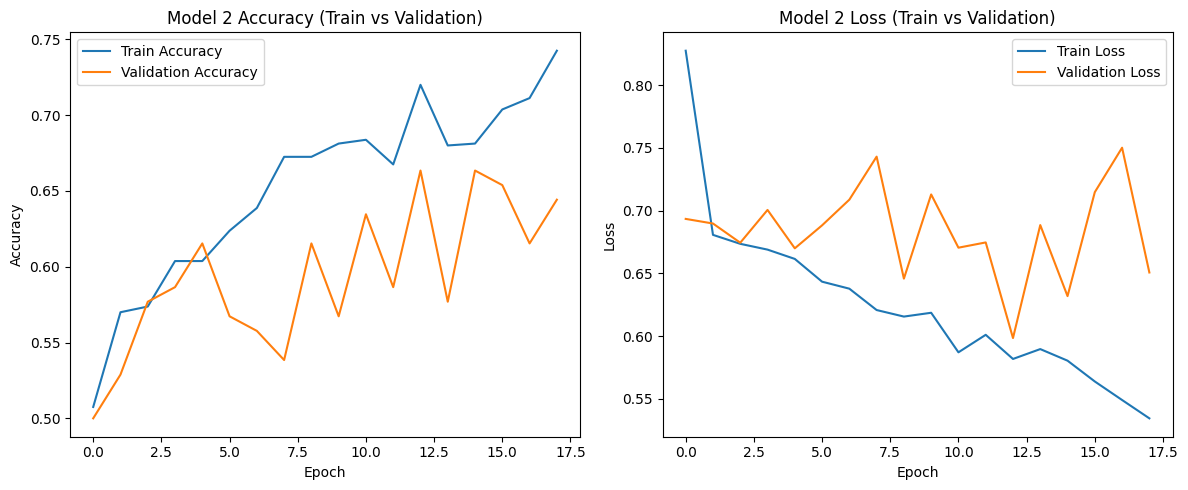

In [42]:
# Visualize training vs validation performance for Model 2

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn_history_2.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 2 Accuracy (Train vs Validation)")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history_2.history["loss"], label="Train Loss")
plt.plot(cnn_history_2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 Loss (Train vs Validation)")
plt.legend()

plt.tight_layout()
plt.show()

Model 2 added stronger data augmentation and dropout regularization to reduce overfitting and improve generalization performance.

Compared to Model 1, the gap between training and validation accuracy became smaller, suggesting that the model relied less on memorizing training images. Validation accuracy also became more stable overall, and test accuracy improved from approximately 56% to 63%.

However, validation loss still fluctuated noticeably across epochs, indicating that the small dataset continued to make generalization difficult. Although overfitting was reduced compared to the previous model, the CNN still struggled to fully generalize to unseen images.

# Model 3: Larger CNN with Batch Normalization


In [43]:
# This experiment tests whether increasing CNN capacity and adding
# batch normalization improves feature learning and training stability.

tf.random.set_seed(42)

data_augmentation_3 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

early_stopping_3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

cnn_model_3 = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    data_augmentation_3,

    # convolution block 1
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # convolution block 2
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # convolution block 3
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # classification layers
    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

cnn_model_3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_history_3 = cnn_model_3.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_3]
)

cnn_test_loss_3, cnn_test_acc_3 = cnn_model_3.evaluate(test_ds_padded)

print(f"Model 3 Test Accuracy: {cnn_test_acc_3:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 865ms/step - accuracy: 0.5288 - loss: 3.9639 - val_accuracy: 0.4904 - val_loss: 0.6873
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 978ms/step - accuracy: 0.5475 - loss: 0.7199 - val_accuracy: 0.5096 - val_loss: 0.6931
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 811ms/step - accuracy: 0.5713 - loss: 0.6851 - val_accuracy: 0.4904 - val_loss: 0.6931
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 940ms/step - accuracy: 0.5663 - loss: 0.6785 - val_accuracy: 0.4327 - val_loss: 0.6944
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 676ms/step - accuracy: 0.5700 - loss: 0.6787 - val_accuracy: 0.5096 - val_loss: 0.6930
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 667ms/step - accuracy: 0.5525 - loss: 0.6852 - val_accuracy: 0.4712 - val_loss: 0.6938
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.5417 - loss: 0.6498
Model 3 Test Accuracy: 0.5417


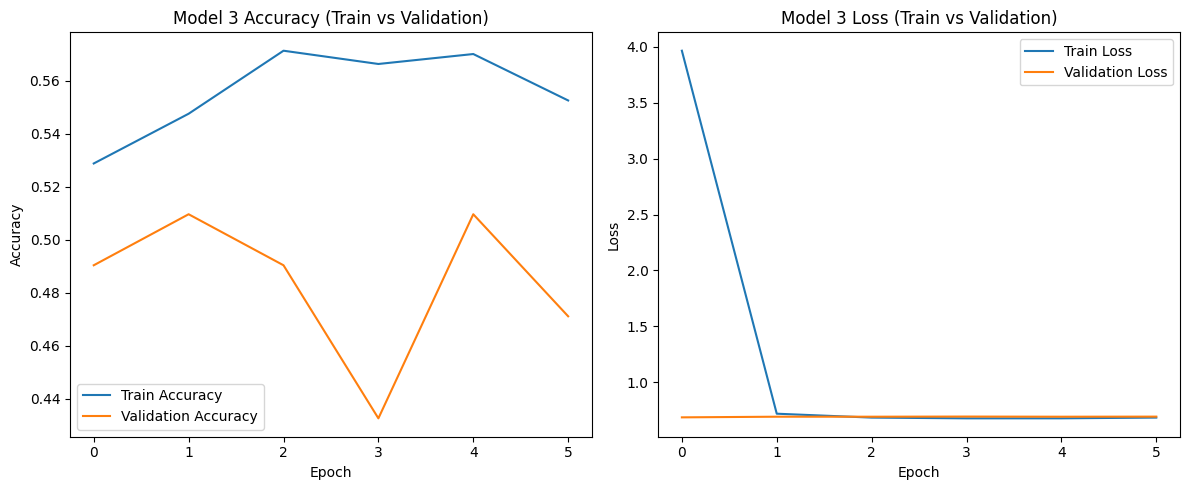

In [44]:
# Visualize training vs validation performance for Model 3

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    cnn_history_3.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    cnn_history_3.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 3 Accuracy (Train vs Validation)")
plt.legend()

# Loss
plt.subplot(1, 2, 2)

plt.plot(
    cnn_history_3.history["loss"],
    label="Train Loss"
)

plt.plot(
    cnn_history_3.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 Loss (Train vs Validation)")
plt.legend()

plt.tight_layout()
plt.show()

Model 3 increased CNN complexity by adding an additional convolution layer and batch normalization. However, the model showed unstable validation behavior and substantially lower test accuracy compared to Model 2.

The results suggest that increasing model complexity too aggressively on a small dataset made optimization more difficult and reduced generalization performance. This experiment demonstrates that larger CNN architectures do not automatically improve performance, especially when training data is limited.

### What seemed to help model performance most in your experiments?

Across the experiments, the strongest improvement came from using stronger data augmentation and dropout regularization together. Model 2 achieved the best overall CNN test accuracy at approximately 0.6250, compared to approximately 0.5625 for Model 1 and 0.5417 for Model 3.

Compared to the earlier CNN models, stronger augmentation helped reduce memorization of the small training dataset and slightly improved generalization performance on unseen images. The training and validation curves also showed a smaller gap between training and validation accuracy, suggesting reduced overfitting behavior.

In contrast, simply increasing CNN complexity by adding more convolutional layers and batch normalization did not improve performance. Model 3 produced lower validation stability and the weakest test accuracy, demonstrating that additional model capacity does not automatically improve image classification performance on small datasets.

Overall, the experiments showed that controlling overfitting through augmentation and regularization was more effective than aggressively increasing CNN complexity.